In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tensorflow import keras
from sklearn.utils import shuffle
from skimage.transform import resize
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
import glob

In [2]:
damage_train=glob.glob('train_another/damage/*.jpeg')
no_damage_train=glob.glob('train_another/no_damage/*.jpeg')

In [3]:
print(len(damage_train))
print(len(no_damage_train))

5000
5000


In [4]:
damage_test=glob.glob('test_another/damage/*.jpeg')
no_damage_test=glob.glob('test_another/no_damage/*.jpeg')

In [5]:
print(len(damage_test))
print(len(no_damage_test))

8000
1000


In [7]:
image_train=[]
label_train=[]

for i in damage_train:
    img=cv2.imread(i)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img=cv2.resize(img,(128,128))
    image_train.append(img)
    label_train.append(1)

for i in no_damage_train:
    img=cv2.imread(i)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img=cv2.resize(img,(128,128))
    image_train.append(img)
    label_train.append(0)    

In [8]:
image_test=[]
label_test=[]

for i in damage_test:
    img=cv2.imread(i)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img=cv2.resize(img,(128,128))
    image_test.append(img)
    label_test.append(1)

for i in no_damage_test:
    img=cv2.imread(i)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img=cv2.resize(img,(128,128))
    image_test.append(img)
    label_test.append(0)    

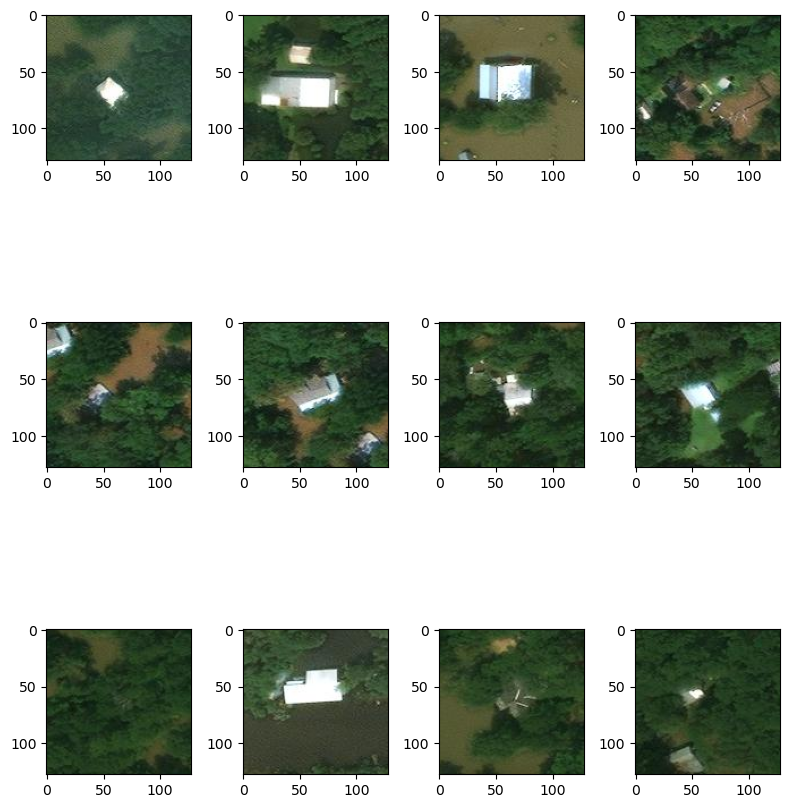

In [9]:
plt.figure(figsize=(8,10))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image_train[i])
plt.tight_layout()

In [10]:
image_train,label_train=shuffle(image_train,label_train,random_state=42)
image_test,label_test=shuffle(image_test,label_test,random_state=42)

In [11]:
X_train=np.array(image_train)
X_test=np.array(image_test)


In [12]:
X_train=X_train/255.0
X_test=X_test/255.0

In [13]:
y_train=np.array(label_train)
y_test=np.array(label_test)

In [15]:
X_train.shape

(10000, 128, 128, 3)

In [16]:
y_train.shape

(10000,)

In [19]:
model=keras.models.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    keras.layers.MaxPool2D(),

    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPool2D(),

    keras.layers.Conv2D(128,(3,3),activation='relu'),
    keras.layers.MaxPool2D(),

    keras.layers.Flatten(),

    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1,activation='sigmoid')
])

In [20]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [21]:
model.fit(X_train,y_train,epochs=20,validation_split=0.1,batch_size=32)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 72s 226ms/step - accuracy: 0.8004 - loss: 0.4328 - val_accuracy: 0.8760 - val_loss: 0.2696
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 64s 228ms/step - accuracy: 0.9157 - loss: 0.2156 - val_accuracy: 0.9120 - val_loss: 0.2017
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 64s 228ms/step - accuracy: 0.9364 - loss: 0.1615 - val_accuracy: 0.9430 - val_loss: 0.1408
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 64s 226ms/step - accuracy: 0.9513 - loss: 0.1211 - val_accuracy: 0.9610 - val_loss: 0.0890
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 64s 227ms/step - accuracy: 0.9572 - loss: 0.1143 - val_accuracy: 0.9640 - val_loss: 0.0910
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 65s 229ms/step - accuracy: 0.9668 - loss: 0.0929 - val_accuracy: 0.9700 - val_loss: 0.0777
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 64s 227ms/step - accuracy: 0.9696 - loss: 0.0806 - val_accuracy: 0.9580 - val_loss: 0.1200
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 64s 226ms/step - accuracy: 0.9766 - loss: 0

In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,914,309 (37.82 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,609,540 (25.21 MB)

In [23]:
loss,accuracy=model.evaluate(X_train,y_train)
print('Loss:',loss)
print('Accuracy:',accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.9940 - loss: 0.0253    
Loss: 0.025291314348578453
Accuracy: 0.9940000176429749


In [68]:
prediction=model.predict(X_test)

282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step


In [69]:
pred=[]

for i in prediction:
    if i>0.7:
        pred.append(1)
    else:
        pred.append(0)

In [70]:
label_dict={1:'Damage',0:'No Damage'}

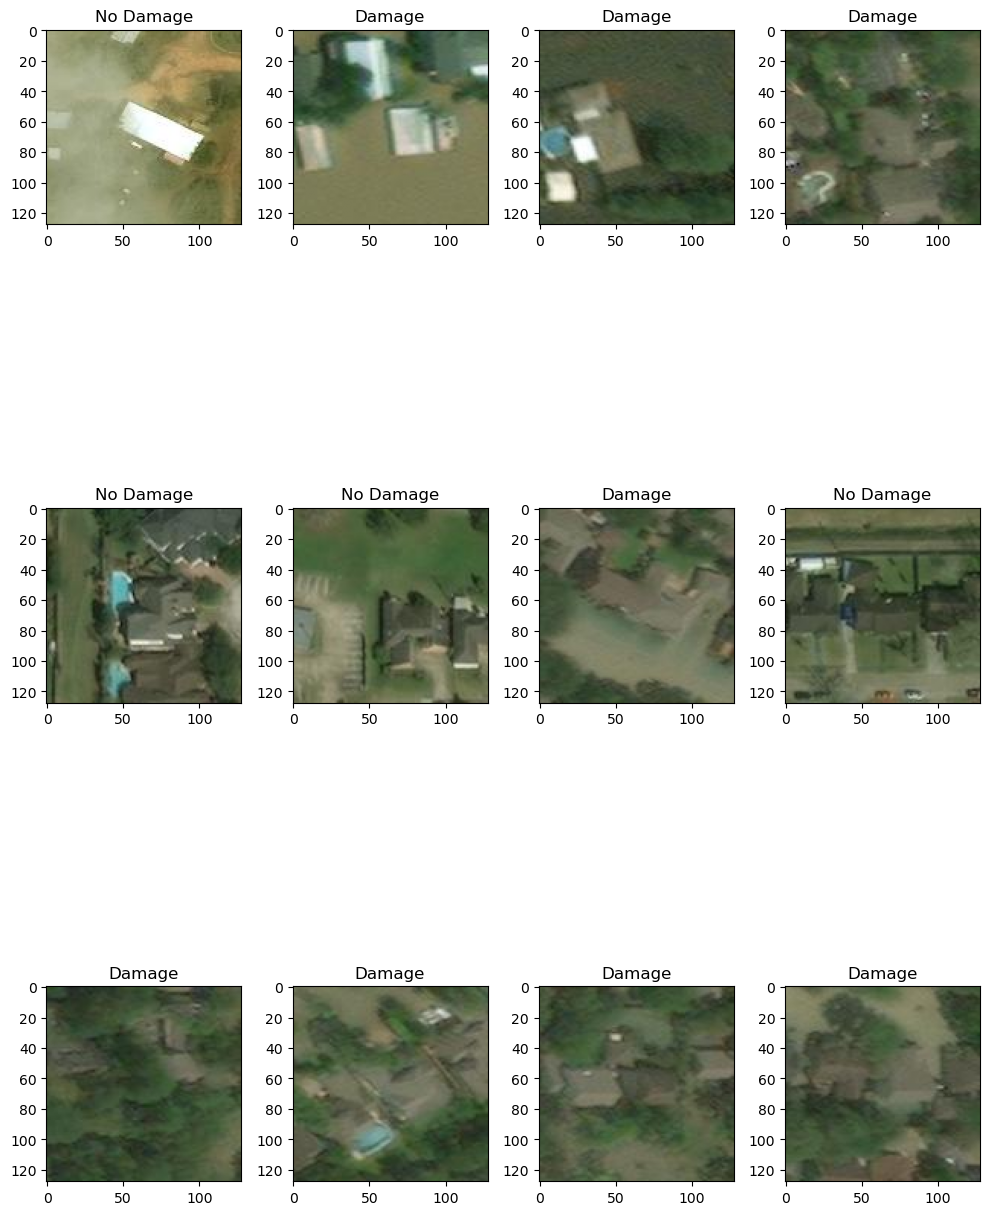

In [71]:
plt.figure(figsize=(10,16))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i])
    plt.title(label_dict[pred[i]])
plt.tight_layout()

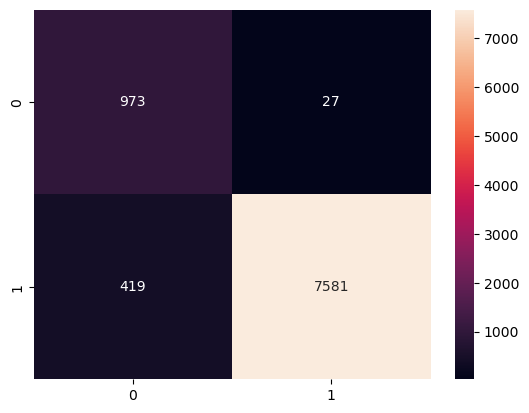

In [72]:
sns.heatmap(confusion_matrix(y_test,pred),annot=True,fmt='d')
plt.show()

In [73]:
accuracy_score(y_test,pred)

0.9504444444444444

In [74]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.70      0.97      0.81      1000
           1       1.00      0.95      0.97      8000

    accuracy                           0.95      9000
   macro avg       0.85      0.96      0.89      9000
weighted avg       0.96      0.95      0.95      9000



In [106]:
test_img1=plt.imread('damage.jpeg')

In [107]:
test_img1=cv2.resize(test_img1,(128,128))
test_img1=np.array(test_img1)
test_img1=np.reshape(test_img1,(1,128,128,3))
test_img1=test_img1/255.0

In [108]:
prediction=model.predict(test_img1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


In [109]:
prediction

array([[5.9447395e-08]], dtype=float32)

In [110]:
pred = (prediction > 0.5).astype(int).flatten()

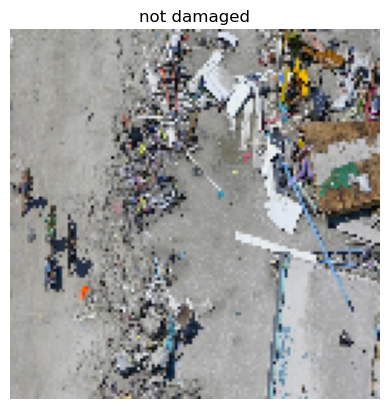

In [118]:
label_dict = {1:'not damaged',0:'damaged'}

plt.imshow(test_img1[0])
plt.title(label_dict[pred[0]])
plt.axis("off")
plt.show()

In [112]:
test_img2=plt.imread('no damage.jpg')

In [113]:
test_img2=cv2.resize(test_img2,(128,128))
test_img2=np.reshape(test_img2,(1,128,128,3))
test_img2=np.array(test_img2)
test_img2=test_img2/255.0

In [114]:
prediction=model.predict(test_img2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step


In [115]:
prediction

array([[1.]], dtype=float32)

In [116]:
pred = (prediction > 0.5).astype(int).flatten()

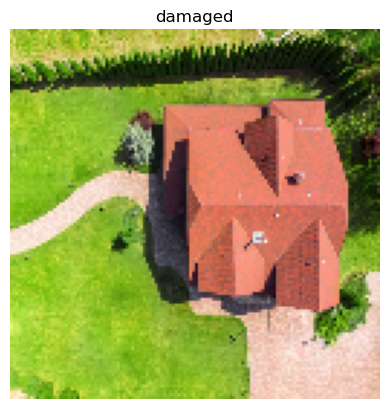

In [117]:
label_dict = {0:'not damaged',1:'damaged'}

plt.imshow(test_img2[0])
plt.title(label_dict[pred[0]])
plt.axis("off")
plt.show()

In [105]:
from sklearn.metrics import confusion_matrix

prediction = model.predict(X_test)
pred = (prediction > 0.5).astype(int)

print(confusion_matrix(y_test, pred))

282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step
[[ 963   37]
 [ 358 7642]]
